# Integer Encoding

In [10]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

import torch

### DictVectorizer
각 단어의 수를 세어놓은 사전에서 BOW 인코딩 벡터를 만든다.
- Bag of Words는 문서가 가지는 모든 단어(Words)를 문맥이나 순서를 무시하고 일괄적으로 단어에 대해 빈도 값을 부여해 피처 값을 추출하는 방법이다.

- 원본 데이터:
  - 첫번째 문서: When you have faults, do not fear to abandon the
  > 허물이 있다면, 버리기를 두려워 말라. (공자)
    - you, fault, fear abandom
  - 두번째 문서: You will face many defeats in life, but never let yourself be defeated.
  > 인생에서 많은 패배에 직면하겠지만 결코 패배하지 말라. (마야 안젤루)
    - you, face defeat, life, let, defeat


각 문서별 단어의 수를 정리하면,
- `you`는 모든 문장에서 사용됨
- `defeat`는 하나의 문장에서 여러번 사용됨
```python
[{'you': 1, 'fault': 1, 'fear':1, 'abandom':1},
{'you': 1, 'face': 1. 'defeat':2, 'life':1, 'let':1}]
```

In [11]:
from sklearn.feature_extraction import DictVectorizer

vect = DictVectorizer(sparse=False)

In [12]:
data = [{'A': 1, 'B': 2}, {'B': 3, 'C': 1}]

X = vect.fit_transform(data) # 인코딩 수치 벡터로 변환(X)

X는 아래와 같이 변환됨
> {'A': 1, 'B': 2} -> [1, 2, 0]
> {'B': 3, 'C': 1} -> [0, 3, 1]

In [13]:
X

array([[1., 2., 0.],
       [0., 3., 1.]])

In [14]:
vect.feature_names_

['A', 'B', 'C']

In [15]:
vect.transform({'A': 1, 'E': 3}) # E는 제외됨

array([[1., 0., 0.]])

In [16]:
vect.transform({'C': 4, 'D': 3}) # D는 제외됨

array([[0., 0., 4.]])

In [17]:
vect.transform({'B': 4, 'T': 3})

array([[0., 4., 0.]])

In [18]:
vect.transform([{'B': 4, 'T': 3}, {'C': 4, 'A': 3}])

array([[0., 4., 0.],
       [3., 0., 4.]])

### CountVectorizer
> 문서 집합에서 단어 토큰을 생성하고 각 단어의 수를 세어 BOW 인코딩 벡터를 만든다.

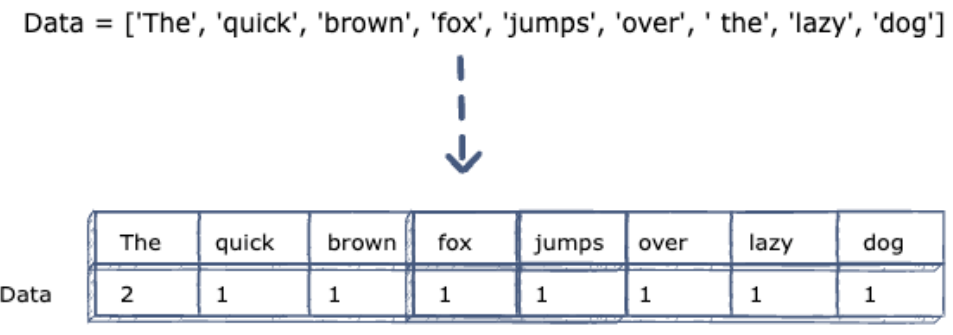

In [19]:
from sklearn.feature_extraction.text import CountVectorizer

In [20]:
corpus = [
    'This is the first document.',
    'This is the second second documents.',
    'And the third one.',
    'Is this the first document?',
    'The last document?',
]

In [21]:
vect = CountVectorizer() # 객체화

# 학습 -> 어간추출/표제어추출하지 못함!!! 단순 단어 카운트
vect.fit(corpus)

vect.vocabulary_ # 학습 데이터 확인

{'this': 10,
 'is': 4,
 'the': 8,
 'first': 3,
 'document': 1,
 'second': 7,
 'documents': 2,
 'and': 0,
 'third': 9,
 'one': 6,
 'last': 5}

In [22]:
vect.transform(['This This is the second document.']).toarray()

array([[0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 2]])

In [23]:
vect.transform(['Something completely new.']).toarray()

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

In [24]:
corpus

['This is the first document.',
 'This is the second second documents.',
 'And the third one.',
 'Is this the first document?',
 'The last document?']

In [25]:
vect.transform(corpus).toarray()

array([[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1],
       [0, 0, 1, 0, 1, 0, 0, 2, 1, 0, 1],
       [1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0],
       [0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1],
       [0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0]])

#### stop words
> stop words는 문서에서 단어장을 생성할 때 무시할 수 있는 단어를 말한다. 보통 관사, 접속사, 조사 등이 여기에 해당한다.

In [26]:
# stop words(and, is, the, this)를 제외한 데이터를 학습해줘!
vect = CountVectorizer(stop_words=["and", "is", "the", "this"])\
  .fit(corpus)

# stop words가 제외된 어휘집 생성!
vect.vocabulary_

{'first': 2,
 'document': 0,
 'second': 5,
 'documents': 1,
 'third': 6,
 'one': 4,
 'last': 3}

In [27]:
# 결과는 2차원 메트릭스이다.
# 1차원의 뜻 -> 문장의 수
# 2차원의 뜻 -> 어휘집에 정의된 토큰의 수
vect.transform(corpus).toarray()

array([[1, 0, 1, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 2, 0],
       [0, 0, 0, 0, 1, 0, 1],
       [1, 0, 1, 0, 0, 0, 0],
       [1, 0, 0, 1, 0, 0, 0]])

#### token
> analyzer, tokenizer 등의 인수로 사용할 토큰 생성기를 선택할 수 있다.

In [28]:
# analyzer="char" -> 단어가 아닌 문자단위로 토큰화 진행
vect = CountVectorizer(analyzer="char").fit(corpus)

# 어휘집에는 단어가 아닌 문자단위로 생성
vect.vocabulary_

{'t': 16,
 'h': 8,
 'i': 9,
 's': 15,
 ' ': 0,
 'e': 6,
 'f': 7,
 'r': 14,
 'd': 5,
 'o': 13,
 'c': 4,
 'u': 17,
 'm': 11,
 'n': 12,
 '.': 1,
 'a': 3,
 '?': 2,
 'l': 10}

In [29]:
corpus

['This is the first document.',
 'This is the second second documents.',
 'And the third one.',
 'Is this the first document?',
 'The last document?']

In [30]:
# CountVectorizer는 모든 문장의 길이와 상관없이,
# 결과물의 백터 길이(어휘집의 길이)가 같다.
# 따라서 Padding을 할 필요가 없다.
vect.transform(corpus).toarray()

array([[4, 1, 0, 0, 1, 1, 2, 1, 2, 3, 0, 1, 1, 1, 1, 3, 4, 1],
       [5, 1, 0, 0, 3, 3, 4, 0, 2, 2, 0, 1, 3, 3, 0, 5, 3, 1],
       [3, 1, 0, 1, 0, 2, 2, 0, 2, 1, 0, 0, 2, 1, 1, 0, 2, 0],
       [4, 0, 1, 0, 1, 1, 2, 1, 2, 3, 0, 1, 1, 1, 1, 3, 4, 1],
       [2, 0, 1, 1, 1, 1, 2, 0, 1, 0, 1, 1, 1, 1, 0, 1, 3, 1]])

#### nltk(형태소 분석기)
- 오래된 영어 전용 형태소 분석기입니다.

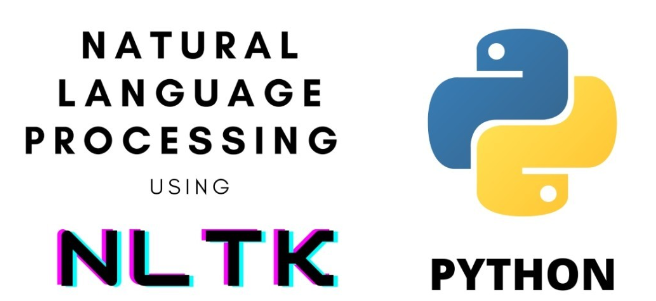

In [31]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [32]:
# nltk(형태소 분석)을 통해 토큰화
nltk.word_tokenize("This is a book")

['This', 'is', 'a', 'book']

In [33]:
# 학습 -> 형태소 분석(nltk)을 적용하여 학습진행
vect = CountVectorizer(tokenizer=nltk.word_tokenize).fit(corpus)

# 해당 어휘집은 nltk의 토큰화에 대한 결과물
vect.vocabulary_

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


{'this': 12,
 'is': 6,
 'the': 10,
 'first': 5,
 'document': 3,
 '.': 0,
 'second': 9,
 'documents': 4,
 'and': 2,
 'third': 11,
 'one': 8,
 '?': 1,
 'last': 7}

#### N-gram
> N-gram은 단어장 생성에 사용할 토큰의 크기를 결정한다. 모노그램(monogram)은 토큰 하나만 단어로 사용하며 바이그램(bigram)은 두 개의 연결된 토큰을 하나의 단어로 사용한다.

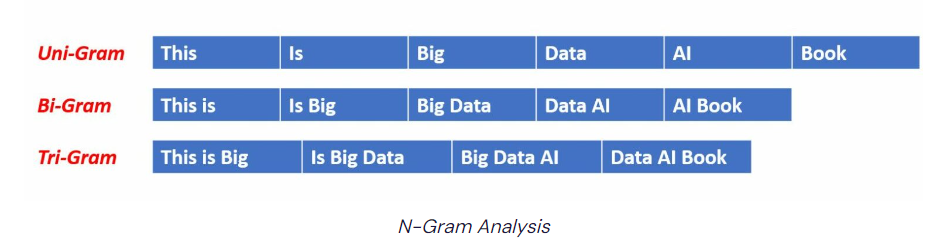

In [34]:
# 최소 2개, 최대 2개 문자로 구성 -> 토큰화를 할 때, Bi-Gram만 진행
vect = CountVectorizer(ngram_range=(2, 2)).fit(corpus)
vect.vocabulary_

{'this is': 12,
 'is the': 2,
 'the first': 7,
 'first document': 1,
 'the second': 9,
 'second second': 6,
 'second documents': 5,
 'and the': 0,
 'the third': 10,
 'third one': 11,
 'is this': 3,
 'this the': 13,
 'the last': 8,
 'last document': 4}

In [35]:
# 최소 1개(Uni-Gram), 최대 2개(Bi-Gram) 문자로 구성
# -> 토큰화를 할 때, Uni-Gram & Bi-Gram만 진행
vect = CountVectorizer(ngram_range=(1, 2)).fit(corpus)
vect.vocabulary_

{'this': 22,
 'is': 6,
 'the': 15,
 'first': 4,
 'document': 2,
 'this is': 23,
 'is the': 7,
 'the first': 16,
 'first document': 5,
 'second': 12,
 'documents': 3,
 'the second': 18,
 'second second': 14,
 'second documents': 13,
 'and': 0,
 'third': 20,
 'one': 11,
 'and the': 1,
 'the third': 19,
 'third one': 21,
 'is this': 8,
 'this the': 24,
 'last': 9,
 'the last': 17,
 'last document': 10}

#### 빈도수
> `max_df, min_df`인수를 사용하여 문서에서 토큰이 나타난 횟수를 기준으로 단어장을 구성할 수도 있다.
> 토큰의 빈도가 `max_df`로 지장한 값을 초과 하거나 `min_df`로 지정한 값보다 작은 경우에는 무시한다.

In [36]:
corpus

['This is the first document.',
 'This is the second second documents.',
 'And the third one.',
 'Is this the first document?',
 'The last document?']

In [37]:
# 단어별 빈도수: 최대 4개, 최소 2개
vect1 = CountVectorizer().fit(corpus)

vect1.vocabulary_

{'this': 10,
 'is': 4,
 'the': 8,
 'first': 3,
 'document': 1,
 'second': 7,
 'documents': 2,
 'and': 0,
 'third': 9,
 'one': 6,
 'last': 5}

In [38]:
# 단어별 빈도수: 최대 4개, 최소 2개
vect2 = CountVectorizer(max_df=4, min_df=2).fit(corpus)

# the(4개), second(2개), documents(1개), and(1개), third(1개), one(1개), last(1개)
# -> 해당 단어 생략
vect2.vocabulary_

{'this': 3, 'is': 2, 'first': 1, 'document': 0}

In [39]:
corpus

['This is the first document.',
 'This is the second second documents.',
 'And the third one.',
 'Is this the first document?',
 'The last document?']

### TfidfVectorizer
- `CountVectorizer`와 비슷하지만 TF-IDF 방식으로 단어의 가중치를 조정한 BOW 인코딩 벡터를 만든다.
  - `TF`: 문장 내 특정한 단어의 빈도수
  - `DF`: 문장들에서 단어의 빈도수

```python
Doc1 = [
  'Term1','Term1','Term1','Term1','Term1',
  'Term2',
  'Term3','Term3','Term3','Term3','Term3',
  'Term4','Term4','Term4',
  'Term5','Term5','Term5']
Doc2 = [
  'Term3','Term3','Term3','Term3','Term3',
  'Term4','Term4','Term4']
...
```

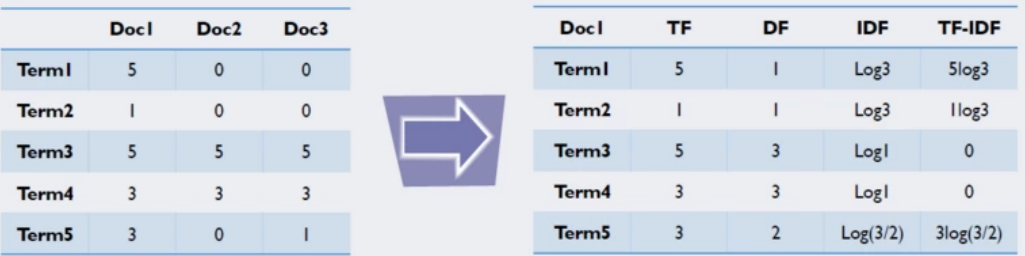

In [40]:
corpus

['This is the first document.',
 'This is the second second documents.',
 'And the third one.',
 'Is this the first document?',
 'The last document?']

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidv = TfidfVectorizer().fit(corpus)

# 첫번째 차원 정보는 문장의 수와 같다.
# 두번째 차원 정보는 Tfidf의 토큰 수와 같다.
tfidv.transform(corpus).toarray()

array([[0.        , 0.44912566, 0.        , 0.54105637, 0.44912566,
        0.        , 0.        , 0.        , 0.31955661, 0.        ,
        0.44912566],
       [0.        , 0.        , 0.40409121, 0.        , 0.27062459,
        0.        , 0.        , 0.80818242, 0.19255163, 0.        ,
        0.27062459],
       [0.55666851, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.55666851, 0.        , 0.26525553, 0.55666851,
        0.        ],
       [0.        , 0.44912566, 0.        , 0.54105637, 0.44912566,
        0.        , 0.        , 0.        , 0.31955661, 0.        ,
        0.44912566],
       [0.        , 0.51737618, 0.        , 0.        , 0.        ,
        0.77253573, 0.        , 0.        , 0.36811741, 0.        ,
        0.        ]])

In [42]:
# Tfidf의 토큰 수
tfidv.get_feature_names_out()

array(['and', 'document', 'documents', 'first', 'is', 'last', 'one',
       'second', 'the', 'third', 'this'], dtype=object)

In [43]:
# 해당 숫자 데이터는 전체 데이터에서 해당 토큰의 중요도를 표현함
# -> 각 문장마다 토큰의 중요도가 다르게 표현됨
pd.DataFrame(tfidv.transform(corpus).toarray(), columns = tfidv.get_feature_names_out())

,and,document,documents,first,is,last,one,second,the,third,this
0,0.000000,0.449126,0.000000,0.541056,0.449126,0.000000,0.000000,0.000000,0.319557,0.000000,0.449126
1,0.000000,0.000000,0.404091,0.000000,0.270625,0.000000,0.000000,0.808182,0.192552,0.000000,0.270625
2,0.556669,0.000000,0.000000,0.000000,0.000000,0.000000,0.556669,0.000000,0.265256,0.556669,0.000000
3,0.000000,0.449126,0.000000,0.541056,0.449126,0.000000,0.000000,0.000000,0.319557,0.000000,0.449126
4,0.000000,0.517376,0.000000,0.000000,0.000000,0.772536,0.000000,0.000000,0.368117,0.000000,0.000000


## WordCloud
> 단어구름 만들어 시각화하기

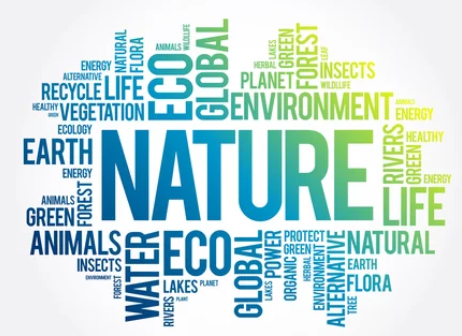

In [44]:
!pip install wordcloud

In [45]:
from wordcloud import WordCloud

wc = WordCloud(background_color="white", width=500, height=500)

In [46]:
corpus = [
    'If you eat all three meals, you’ll gain weight.', # 세끼 다 먹으면 살쪄요. (배우 김사랑)
    'You think you’re trying a new flavor, but it’s one you already know.', # 먹어 봤자, 내가 아는 그 맛이다. (배우 옥주현)
    'You are not hungry. You are bored. Learn the differnce.', #  당신은 배고픈 것이 아니라 단지 지루함을 느낄 뿐이다. 차이점을 배워라. (익명)
    'The reason I exercise is for the quality of life I enjoy.', # 내가 운동하는 이유는 삶의 질을 높여 인생을 즐기기 위함이다. (익명)
    'When you feel like stopping , think about why you started.', # 그만두고 싶다는 생각이 되면 왜 시작했는지 생각해 보라. (익명)
    'Reading is to the mind as what exercise is to the body.', # 독서는 마음을 위한 것이고 운동은 몸을 위한 것이다. (익명)
    'Life begins at the end of your comfort zone.', # 인생은 당신이 편안한 환경에서 빠져 나올 때 부터 시작된다. (익명)
    'The only bad workout is the one that didn’t happen.', # 세상에 있는 유일한 나쁜 운동은 안 하는 운동 뿐이다. (익명)
    'To change your body you must first change your mind.', # 체형을 바꾸기 위해서는 먼저 마음 가짐을 바꿔야 한다. (익명)
    'Confidence will make you happier than any diet will.', # 자신감은 그 어떤 다이어트 보다 너를 행복하게 만들어 준다. (익명)
]

In [47]:
vect = CountVectorizer(stop_words=["and", "are", "is", "the", "to"])

tdm = vect.fit_transform(corpus)
tdm

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 78 stored elements and shape (10, 65)>

In [48]:
df_tdm = pd.DataFrame(tdm.toarray(),columns=vect.get_feature_names_out())
df_tdm

,about,all,already,any,as,at,bad,begins,body,bored,...,trying,weight,what,when,why,will,workout,you,your,zone
0,0,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,2,0,0
1,0,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,3,0,0
2,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,2,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,2,0,0
5,0,0,0,0,1,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
6,0,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,1,1
7,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
8,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,2,0
9,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,2,0,1,0,0


In [49]:
df_tdm.sum().to_dict()

{'about': 1,
 'all': 1,
 'already': 1,
 'any': 1,
 'as': 1,
 'at': 1,
 'bad': 1,
 'begins': 1,
 'body': 2,
 'bored': 1,
 'but': 1,
 'change': 2,
 'comfort': 1,
 'confidence': 1,
 'didn': 1,
 'diet': 1,
 'differnce': 1,
 'eat': 1,
 'end': 1,
 'enjoy': 1,
 'exercise': 2,
 'feel': 1,
 'first': 1,
 'flavor': 1,
 'for': 1,
 'gain': 1,
 'happen': 1,
 'happier': 1,
 'hungry': 1,
 'if': 1,
 'it': 1,
 'know': 1,
 'learn': 1,
 'life': 2,
 'like': 1,
 'll': 1,
 'make': 1,
 'meals': 1,
 'mind': 2,
 'must': 1,
 'new': 1,
 'not': 1,
 'of': 2,
 'one': 2,
 'only': 1,
 'quality': 1,
 're': 1,
 'reading': 1,
 'reason': 1,
 'started': 1,
 'stopping': 1,
 'than': 1,
 'that': 1,
 'think': 2,
 'three': 1,
 'trying': 1,
 'weight': 1,
 'what': 1,
 'when': 1,
 'why': 1,
 'will': 2,
 'workout': 1,
 'you': 11,
 'your': 3,
 'zone': 1}

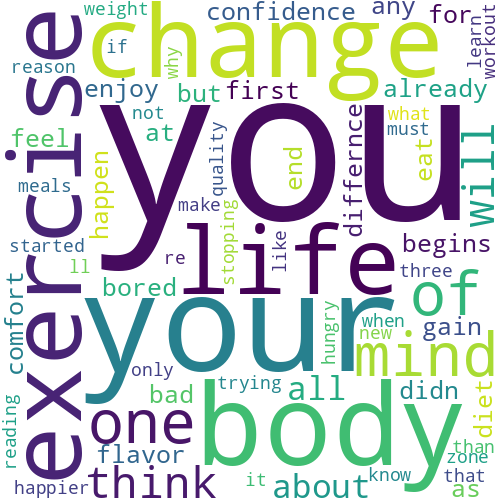

In [50]:
cloud = wc.generate_from_frequencies(df_tdm.sum().to_dict())
cloud.to_image()